In [ ]:
import os
import shutil
import random
from glob import glob

source_dir = "/home/teaching/ADL-project/data/Dataset_BUSI_with_GT"
target_dir = "/home/teaching/ADL-project/data/dataset"

os.makedirs(f"{target_dir}/train", exist_ok=True)
os.makedirs(f"{target_dir}/val", exist_ok=True)

split_ratio = 0.8

images = glob(os.path.join(source_dir, "*", "*.png"))
images = [img for img in images if "_mask" not in os.path.basename(img)]
random.shuffle(images)

split = int(split_ratio * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

for img in train_imgs:
    shutil.copy(img, f"{target_dir}/train/")

for img in val_imgs:
    shutil.copy(img, f"{target_dir}/val/")

print(f"Dataset split completed successfully!")
print(f"Train images: {len(train_imgs)}, Validation images: {len(val_imgs)}")


Dataset split completed successfully!
Train images: 624, Validation images: 156


In [13]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from datasets import load_dataset
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
dataset = {
    "train": glob("/home/teaching/ADL-project/data/dataset/train/*.png"),
    "val": glob("/home/teaching/ADL-project/data/dataset/val/*.png")
}


In [15]:
model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)
model.to(device)
model.train()


GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=96, out_features=96, bias=True)
                        (key): Linear(in_features=9

In [21]:
from PIL import Image
import torch
from torch.optim import AdamW

device = "cuda" if torch.cuda.is_available() else "cpu"

optimizer = AdamW(model.parameters(), lr=5e-5)
confidence_threshold = 0.4
iou_threshold = 0.5

def custom_nms(boxes, scores, iou_threshold):
    import torchvision
    keep = torchvision.ops.nms(boxes, scores, iou_threshold)
    return keep

num_epochs = 1

for epoch in range(num_epochs):
    total_boxes = 0
    for img_path in dataset["train"]:
        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        prompts = ["tumor"] 
        inputs = processor(images=image, text=prompts, return_tensors="pt").to(device)
        
        optimizer.zero_grad()
        outputs = model(**inputs)

        pred_logits = outputs.logits[0]
        pred_boxes = outputs.pred_boxes[0]

        probs = pred_logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)
        mask = scores > confidence_threshold

        if mask.sum() == 0:
            continue 

        filtered_boxes_cxcywh = pred_boxes[mask]
        filtered_scores = scores[mask]

        boxes_xyxy = filtered_boxes_cxcywh.clone()
        boxes_xyxy[:, 0] -= boxes_xyxy[:, 2]/2
        boxes_xyxy[:, 1] -= boxes_xyxy[:, 3]/2
        boxes_xyxy[:, 2] += boxes_xyxy[:, 0]
        boxes_xyxy[:, 3] += boxes_xyxy[:, 1]

        boxes_xyxy[:, [0,2]] *= width
        boxes_xyxy[:, [1,3]] *= height

        keep_indices = custom_nms(boxes_xyxy, filtered_scores, iou_threshold=iou_threshold)
        final_boxes = boxes_xyxy[keep_indices]

        loss = 1 - filtered_scores[keep_indices].mean()
        loss.backward()
        optimizer.step()

        total_boxes += len(final_boxes)

    print(f"Epoch {epoch+1}: Processed {len(dataset['train'])} images, total pseudo-boxes: {total_boxes}")


Epoch 1: Processed 624 images, total pseudo-boxes: 189793


In [23]:
import torch

pseudo_labels = {}

for img_path in dataset["train"]:
    image = Image.open(img_path).convert("RGB")
    width, height = image.size

    prompts = ["tumor"]
    inputs = processor(images=image, text=prompts, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    pred_logits = outputs.logits[0]
    pred_boxes = outputs.pred_boxes[0]

    probs = pred_logits.softmax(-1)[:, :-1]
    scores, labels = probs.max(-1)
    mask = scores > confidence_threshold
    if mask.sum() == 0:
        continue

    filtered_boxes_cxcywh = pred_boxes[mask]
    filtered_scores = scores[mask]

    boxes_xyxy = filtered_boxes_cxcywh.clone()
    boxes_xyxy[:, 0] -= boxes_xyxy[:, 2]/2
    boxes_xyxy[:, 1] -= boxes_xyxy[:, 3]/2
    boxes_xyxy[:, 2] += boxes_xyxy[:, 0]
    boxes_xyxy[:, 3] += boxes_xyxy[:, 1]

    boxes_xyxy[:, [0,2]] *= width
    boxes_xyxy[:, [1,3]] *= height

    keep_indices = custom_nms(boxes_xyxy, filtered_scores, iou_threshold=iou_threshold)
    final_boxes = boxes_xyxy[keep_indices]
    final_scores = filtered_scores[keep_indices]

    pseudo_labels[img_path] = {
        "boxes": final_boxes.cpu(),
        "scores": final_scores.cpu()
    }

torch.save(pseudo_labels, "pseudo_boxes.pt")
print("Pseudo-boxes saved!")


Pseudo-boxes saved!


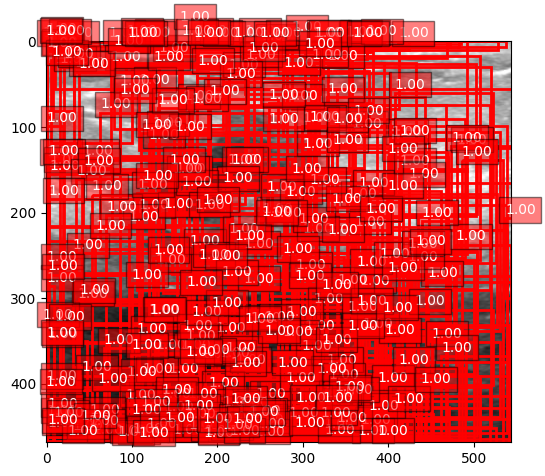

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_path = list(pseudo_labels.keys())[0]
sample = pseudo_labels[sample_path]
image = Image.open(sample_path).convert("RGB")
boxes = sample["boxes"]
scores = sample["scores"]

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.imshow(image)

for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f"{score:.2f}", color='white', bbox=dict(facecolor='red', alpha=0.5))

plt.show()
